# PCAWG SigFormer analysis

Full PCAWG demonstration using bundled raw data and cache-first outputs for comparison methods.

The notebook is intentionally verbose: configuration, inference, visualization, and saving are kept in separate cells so that a user can inspect or rerun each stage independently.

In [1]:
from __future__ import annotations

import datetime as _dt
import os, re, sys, math, time, json, shutil, logging, warnings, subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import SigFormer
from SigFormer.scripts import s04_Util_apply as analysis
from SigFormer.scripts.s06_wrapper import (
    CLASS_wrapper_MuSiCal,
    CLASS_wrapper_SigFormer,
    CLASS_wrapper_SigLASSO,
    CLASS_wrapper_SigProfilerAssignment,
    CLASS_wrapper_sig_tool_lib,
    CLASS_wrapper_sigfit,
)

MASTER_DIR = Path.cwd().resolve()
RESOURCE_DIR = Path(SigFormer.RESOURCE_DIR)

In [2]:
%matplotlib inline

os.environ.setdefault("PYTHONHASHSEED", "717")
torch.set_num_threads(int(os.environ.get("SIGFORMER_NUM_THREADS", "8")))

import logging, warnings
logging.disable(logging.INFO)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

In [3]:
# Create a clean run directory from the bundled PCAWG inputs and cached comparison-method results.

PATH_source = RESOURCE_DIR / 'demo_PCAWG'
PATH_source_raw, PATH_source_ext, PATH_source_cac = (PATH_source / '0_raw', PATH_source / '1_external', PATH_source / '1_cached')
PATH_cohort = MASTER_DIR / 'run_PCAWG'
PATH_cohort_raw, PATH_cohort_ext, PATH_cohort_cac = (PATH_cohort / '0_raw', PATH_cohort / '1_external', PATH_cohort / '1_cached')
PATH_cohort_hmz = PATH_cohort / '2_harmonized_results'
PATH_cohort_UMAP = PATH_cohort / '3_UMAP'
PATH_cohort_CLUS = PATH_cohort / '4_per_cluster'
PATH_cohort_REPL = PATH_cohort / '5_replacement_test'
PATH_cohort__OOC = PATH_cohort / '6_OOC'
shutil.copytree(PATH_source_raw, PATH_cohort_raw, dirs_exist_ok=True)
shutil.copytree(PATH_source_ext, PATH_cohort_ext, dirs_exist_ok=True)
shutil.copytree(PATH_source_cac, PATH_cohort_cac, dirs_exist_ok=True)
for path in [PATH_cohort_hmz, PATH_cohort_UMAP, PATH_cohort_CLUS, PATH_cohort_REPL, PATH_cohort__OOC]:
    analysis.ensure_dir(path)

In [4]:
# Analysis constants, UMAP settings, and all wrapper parameters are explicit in this cell.

RANDOM_STATE = 415
K_NEIGHBORS = 35
PARAM__UMAP = dict(metric='cosine', n_neighbors=K_NEIGHBORS, min_dist=0.3, spread=1.0, init='random', leiden_resolution=2, random_state=RANDOM_STATE)
R_ENV = None
PATH_model = RESOURCE_DIR / 'sigformer_v9_epoch_1600.pt'
PARAM_REFINE = {'hard_composition': 0.005, 'hard_count': 3, 'prior_strength': 12.0, 'max_rescue': 2,
                'candidate_top_k': 6, 'max_l1_change': 0.20, 'max_ood_change': 0.15, 'max_ood_increase': 0.005,
                'rescue_min_composition': 0.01, 'n_channel_folds': 4, 'normalized_effective_depth': 1000, 'random_state': 717, 'version': None,}
PARAM_SgF = dict(PATH_model=str(PATH_model), epoch=None, device=None, simplex='softmax', strict=False, refine=True, refinement_kwargs=PARAM_REFINE)
PARAM_Mus = dict(method='likelihood_bidirectional', thresh=0.001)
PARAM_SPA = dict(PATH_tmp=None, hg_ver='GRCh38', cos_ver=3.4)
PARAM_sft = dict(conda_env=R_ENV, work_dir=None, fail_soft=False, iter=1400, warmup=None, chains=3, cores=1, seed=19970717)
PARAM_sLS = dict(conda_env=R_ENV, work_dir=None, fail_soft=False, conf=0.1, adaptive=True, gamma=1, alpha_min=400, iter_max=None, sd_multiplier=1.0, elastic_net=False, normalize='none',)
PARAM_stl = dict(conda_env=R_ENV, work_dir=None, nmuts_threshold=300, pvalue_threshold=0.15, pvalue_method='normErrorSAD', nmuts_method='residualSSD', fail_soft=False,)
TAG_TO_NAME = {'SgF_raw': 'SigFormer raw',
                   'SgF': 'SigFormer',
                   'Mus': 'MuSiCal',
                   'SPA': 'SigProfilerAssignment',
                   'sft': 'sigfit',
                   'sLS': 'sigLASSO',
                   'stl': 'signature.tools.lib',}
SIG_COLORS = analysis.DEFAULT_SIGNATURE_COLORS.copy()
METHOD_COLORS = analysis.METHOD_COLORS.copy()

---

## 1. Input and harmonized references

In [5]:
# Load PCAWG SBS96 counts and metadata, then apply the shared depth filter.

VEC_sub_ctx = analysis.VEC_sub_ctx
X_raw_prof = pd.read_csv(PATH_cohort_raw / 'x_PCAWG_3nt.tsv', sep='\t', index_col=0).loc[:, VEC_sub_ctx]
M_smp_meta = pd.read_csv(PATH_cohort_raw / 'x_PCAWG_ann.tsv', sep='\t', index_col=0)
keep = M_smp_meta['depth'] >= 200
X_raw_prof, M_smp_meta = (X_raw_prof.loc[keep], M_smp_meta.loc[keep])
X_raw_prof.to_csv(PATH_cohort_hmz / '02_input_profile_matrix.tsv', sep='\t')
M_smp_meta.to_csv(PATH_cohort_hmz / '04_per_sample_metadata.tsv', sep='\t')
print(f'{len(X_raw_prof):,}/{len(keep):,} retained after depth >= 200')

2,705/2,780 retained after depth >= 200


In [6]:
# Harmonize PCAWG and published MuSiCal signature names onto the COSMIC v3.4 reference.

R_cosmic34 = pd.read_csv(RESOURCE_DIR / 'r_COSMIC_v3.4_SBS_GRCh38.tsv', sep='\t', index_col=0).loc[:, VEC_sub_ctx]
R_pcawg = pd.read_csv(PATH_cohort_ext / 'r_COSMIC_v3.0_SBS_GRCh37.tsv', sep='\t', index_col=0).loc[:, VEC_sub_ctx]
R_mus_pub = pd.read_csv(PATH_cohort_ext / 'r_MuSiCal_customized.tsv', sep='\t', index_col=0).loc[:, VEC_sub_ctx]
R_pcawg, align_pcawg, map_pcawg = analysis.align_ref_names(R_pcawg, R_cosmic34, 'PCAWG')
R_mus_pub, align_mus_pub, map_mus_pub = analysis.align_ref_names(R_mus_pub, R_cosmic34, 'MuSiCal')
align_records = pd.concat([align_pcawg, align_mus_pub], ignore_index=True)
R_harmonized = analysis.merge_signature_dfs(R_cosmic34, R_pcawg, R_mus_pub)
R_harmonized.to_csv(PATH_cohort_hmz / '01_reference_harmonized.tsv', sep='\t')
align_records.to_csv(PATH_cohort_hmz / '01_reference_harmonization_records.tsv', sep='\t', index=False)
for label, frame in {'COSMIC_v3.4': R_cosmic34, 'PCAWG': R_pcawg, 'MuSiCal': R_mus_pub}.items():
    frame.to_csv(PATH_cohort_hmz / f'01_reference_{label}.tsv', sep='\t')
display(align_records.groupby(['source', 'category']).size().unstack(fill_value=0))

category,denovo,like,same
source,,,
MuSiCal,6,1,77
PCAWG,0,1,66


---

## 2. All-method inference, 500-sample chunks, cache first

In [7]:
# Point external wrappers to run-specific temporary folders and define cache locations.

PARAM_SPA['PATH_tmp'] = str(PATH_cohort / '_tmp/SigProfilerAssignment')
PARAM_sft['work_dir'] = str(PATH_cohort / '_tmp/sigfit')
PARAM_sLS['work_dir'] = str(PATH_cohort / '_tmp/sigLASSO')
PARAM_stl['work_dir'] = str(PATH_cohort / '_tmp/signature_tools_lib')
CACHE_PATHS = {'Mus': PATH_cohort_cac / 'y_PCAWG_MuSiCal.tsv',
               'SPA': PATH_cohort_cac / 'y_PCAWG_SigProfilerAssignment.tsv',
               'sft': PATH_cohort_cac / 'y_PCAWG_sigfit.tsv',
               'sLS': PATH_cohort_cac / 'y_PCAWG_SigLASSO.tsv',
               'stl': PATH_cohort_cac / 'y_PCAWG_sig_tool_lib.tsv',}

In [ ]:
# Build one runner dictionary and run cache-first inference in 500-sample chunks.

model_SgF = CLASS_wrapper_SigFormer(**PARAM_SgF)
DICT_runner = {'SgF_raw': model_SgF.predict_raw,
                   'SgF': model_SgF,
                   'Mus': CLASS_wrapper_MuSiCal(**PARAM_Mus),
                   'SPA': CLASS_wrapper_SigProfilerAssignment(**PARAM_SPA),
                   'sft': CLASS_wrapper_sigfit(**PARAM_sft),
                   'sLS': CLASS_wrapper_SigLASSO(**PARAM_sLS),
                   'stl': CLASS_wrapper_sig_tool_lib(**PARAM_stl),}

DICT_res = analysis.run_methods(X_raw_prof, R_cosmic34, DICT_runner, cache_paths=CACHE_PATHS, df_refmask=None, chunk_size=500, method_names=TAG_TO_NAME, save_cache=True, verbose=True)
OUTPUT_FILE_NAMES = {'SigFormer raw': 'SigFormer_raw',
                         'SigFormer': 'SigFormer',
                           'MuSiCal': 'MuSiCal_refit',
             'SigProfilerAssignment': 'SigProfiler',
                            'sigfit': 'sigfit',
                          'sigLASSO': 'SigLASSO',
               'signature.tools.lib': 'sig.tool.lib',}
for method, result in DICT_res.items():
    result['compo'].to_csv(PATH_cohort_hmz / f'03_decomposition_{OUTPUT_FILE_NAMES[method]}.tsv', sep='\t')
if 'diagnostics' in DICT_res['SigFormer']:
    DICT_res['SigFormer']['diagnostics'].to_csv(PATH_cohort_hmz / '03_decomposition_SigFormer_refinement_diagnostics.tsv', sep='\t')

In [9]:
# Add published PCAWG and MuSiCal decompositions using their harmonized reference bases.

df = pd.read_csv(PATH_cohort_ext / 'y_PCAWG_original.tsv', sep='\t', index_col=0).reindex(X_raw_prof.index)
df.columns = df.columns.map(map_pcawg)
df = analysis.sum_scale(df)
ref = R_harmonized.reindex(df.columns)
DICT_res['PCAWG official'] = {'compo': df, 'ood': (1 - df.sum(1)).clip(lower=0), 'recon': df @ ref}
df = pd.read_csv(PATH_cohort_ext / 'y_PCAWG_MuSiCal_published.tsv', sep='\t', index_col=0).reindex(X_raw_prof.index)
df.columns = df.columns.map(map_mus_pub)
df = analysis.sum_scale(df)
ref = R_harmonized.reindex(df.columns)
DICT_res['MuSiCal published'] = {'compo': df, 'ood': (1 - df.sum(1)).clip(lower=0), 'recon': df @ ref}
METHOD_ORDER = ['PCAWG official', 'SigFormer', 'MuSiCal published', 'MuSiCal', 'SigProfilerAssignment', 'sigfit', 'sigLASSO', 'signature.tools.lib']

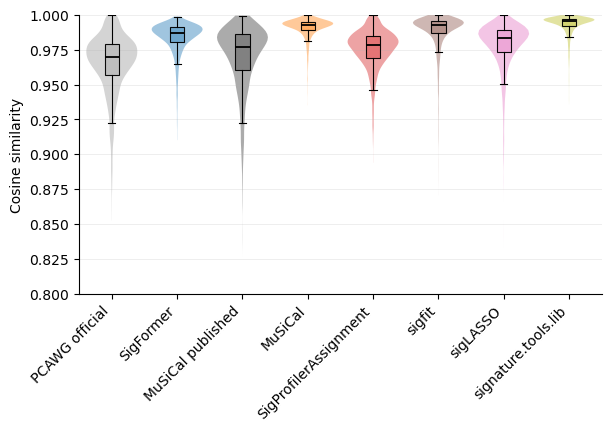

In [10]:
# Compare reconstruction cosine similarity across all available methods.

method_order = [m for m in METHOD_ORDER if m in DICT_res]
cosine_results = {}
for method in method_order:
    recon = DICT_res[method]['recon']
    samples = X_raw_prof.index.intersection(recon.index, sort=False)
    channels = X_raw_prof.columns.intersection(recon.columns, sort=False)
    raw = X_raw_prof.loc[samples, channels].to_numpy(float)
    pred = recon.loc[samples, channels].to_numpy(float)
    denominator = np.linalg.norm(raw, axis=1) * np.linalg.norm(pred, axis=1)
    cosine_results[method] = pd.Series(np.divide(np.sum(raw * pred, axis=1), denominator, out=np.full(len(samples), np.nan), where=denominator > 0), index=samples, name=method)
fig, ax = plt.subplots(figsize=(6, 4.2), constrained_layout=True)
analysis.plot_recon_violin(cosine_results, method_order, METHOD_COLORS, ax=ax)
fig.savefig(PATH_cohort_hmz / 'reconstruction_cosine.pdf')
plt.show() ; plt.close(fig)

---

## 3. UMAP, Leiden clustering and geometry

In [11]:
# Fit Raw and method-specific UMAP/Leiden representations using one shared parameter set.

METHOD_TAGS = {
    'SigFormer raw': 'SgF_raw',
    'SigFormer': 'SgF',
    'MuSiCal': 'Mus',
    'SigProfilerAssignment': 'SPA',
    'sigfit': 'sft',
    'sigLASSO': 'sLS',
    'signature.tools.lib': 'stl',
}
umap_meta = M_smp_meta.copy()
umap_results = {}
umap_results['Raw'] = analysis.run_umap_representation(X_raw_prof, umap_meta, 'Raw', PATH_cohort_UMAP, PARAM__UMAP)
for method, tag in METHOD_TAGS.items():
    if method not in DICT_res:
        continue
    print(f'UMAP: {method}')
    umap_results[method] = analysis.run_umap_representation(DICT_res[method]['compo'], umap_meta, tag, PATH_cohort_UMAP, PARAM__UMAP, reference_tag='Raw')
formal_cluster_col = 'Leiden_SgF_2'
umap_meta.to_csv(PATH_cohort_hmz / '04_per_sample_metadata.tsv', sep='\t')

UMAP: SigFormer raw
UMAP: SigFormer
UMAP: MuSiCal
UMAP: SigProfilerAssignment
UMAP: sigfit
UMAP: sigLASSO
UMAP: signature.tools.lib


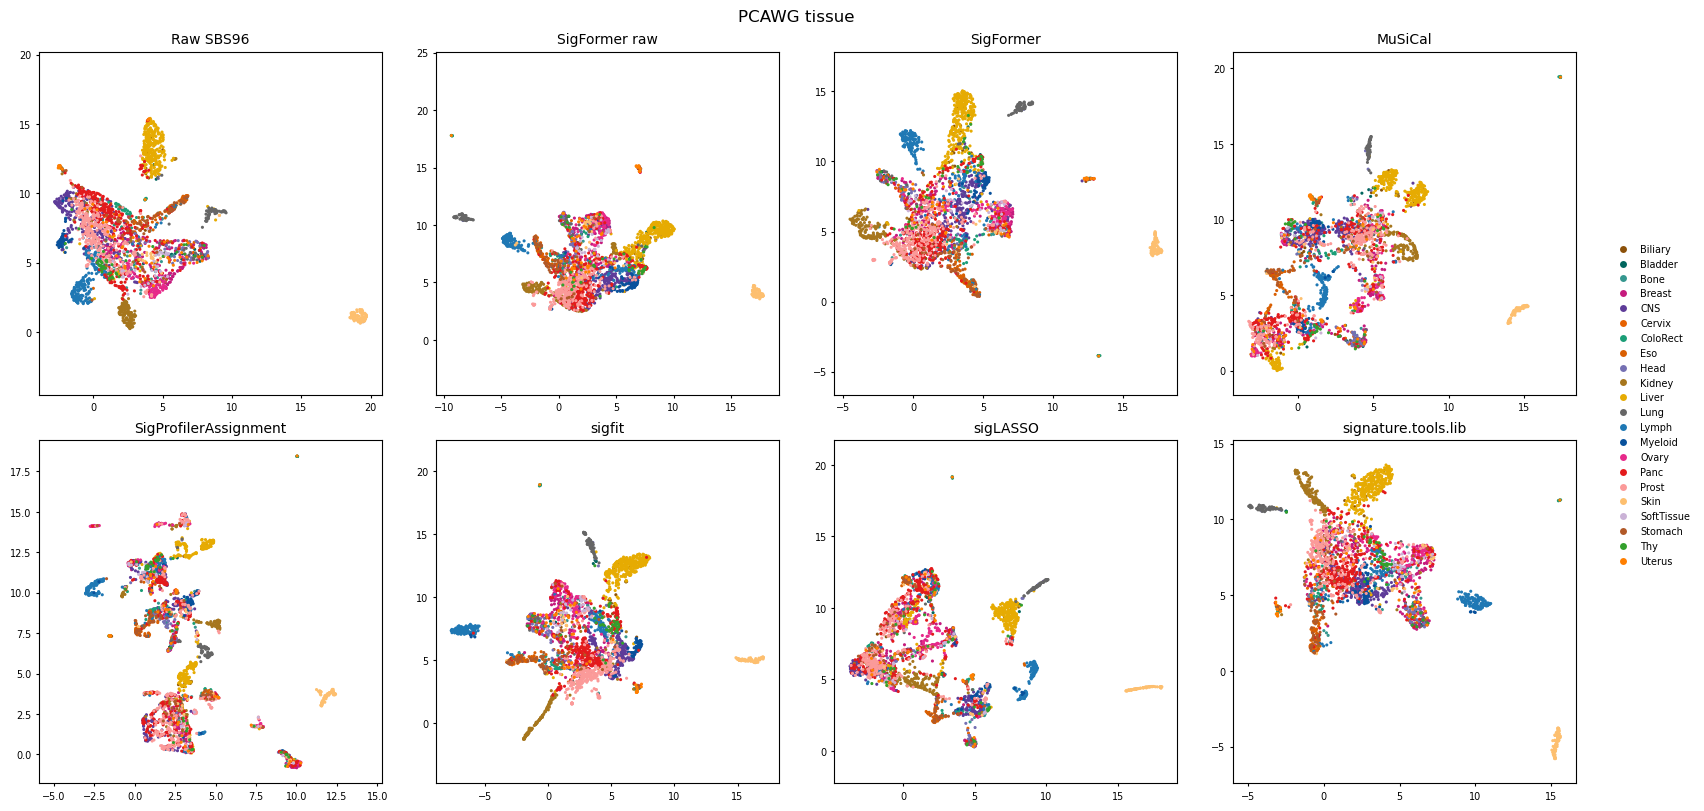

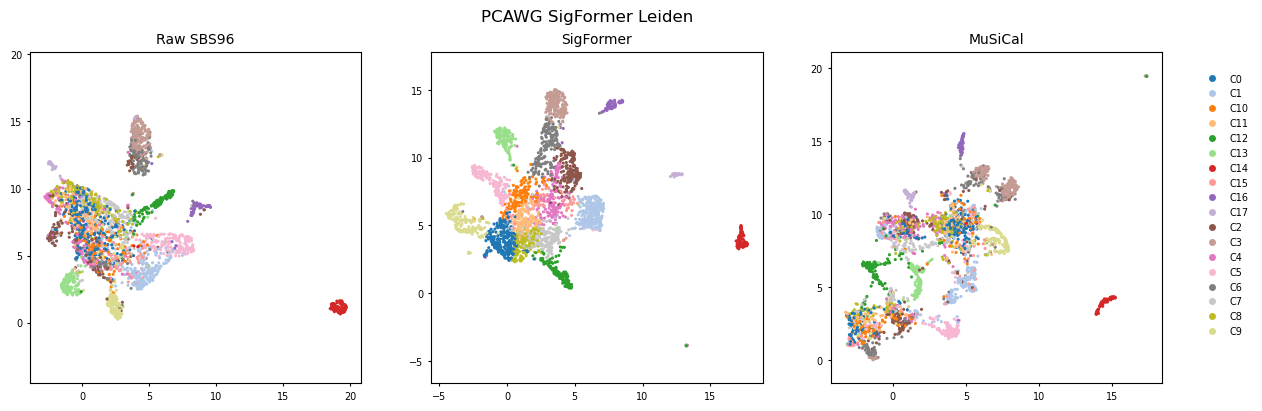

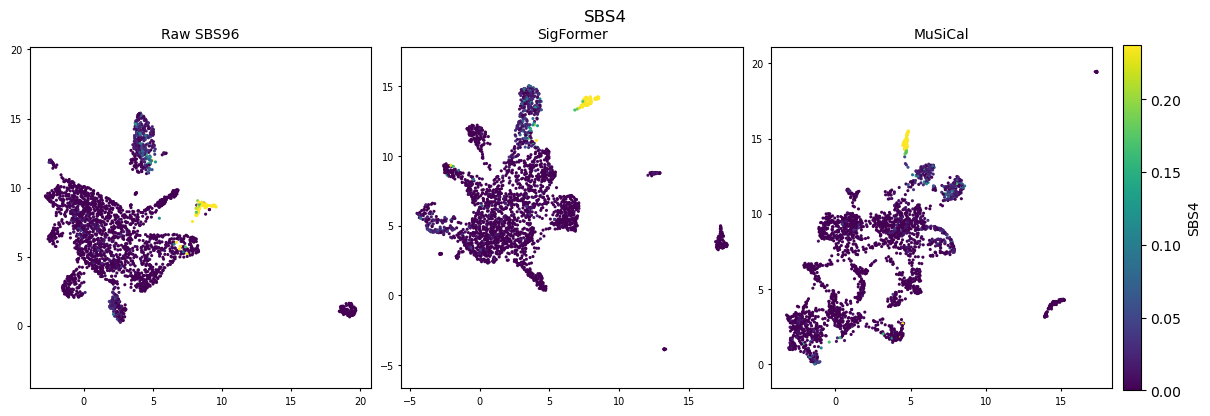

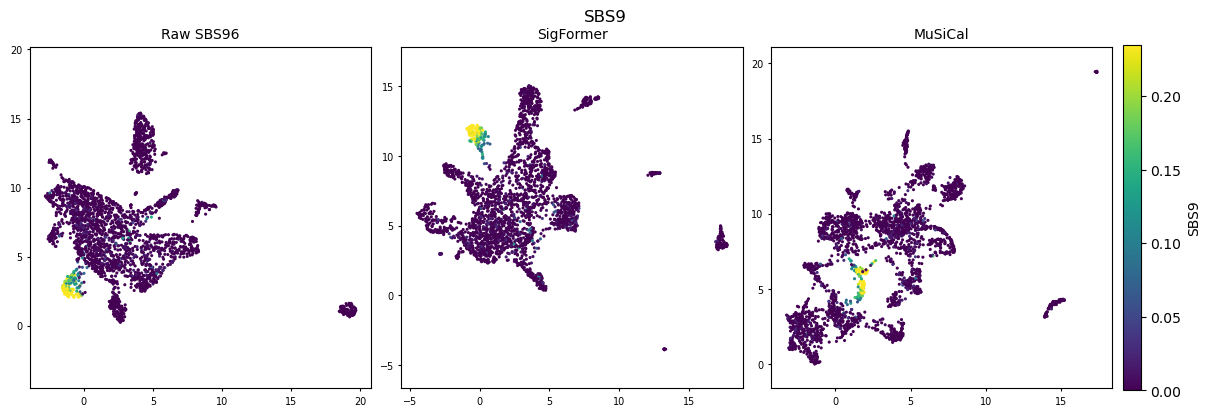

In [12]:
# Visualize tissue, cluster, and selected-signature views with explicit plotting helpers.

panels = [('Raw SBS96', 'Raw')] + [(method, tag) for method, tag in METHOD_TAGS.items() if method in DICT_res]
fig, axes = analysis.plot_umap_grid(umap_meta, panels, M_smp_meta['Tissue'], categorical=True, palette=analysis.TISSUE_COLORS, title='PCAWG tissue')
plt.show()
plt.close(fig)
fig, axes = analysis.plot_umap_grid(umap_meta, [('Raw SBS96', 'Raw'), ('SigFormer', 'SgF'), ('MuSiCal', 'Mus')], umap_meta[formal_cluster_col], categorical=True, title='PCAWG SigFormer Leiden')
plt.show()
plt.close(fig)
for sig in ['SBS4', 'SBS9']:
    fig, axes = analysis.plot_umap_grid(umap_meta, [('Raw SBS96', 'Raw'), ('SigFormer', 'SgF'), ('MuSiCal', 'Mus')], DICT_res['SigFormer']['compo'].get(sig, 0), categorical=False, title=sig)
    plt.show() ; plt.close(fig)

In [13]:
# Quantify local/global geometry preservation independently of the UMAP visualization.

geometry = analysis.geometry_metrics(X_raw_prof, DICT_res, k=K_NEIGHBORS, max_pairs=50000, random_state=RANDOM_STATE, knn_graphs=None)
display(geometry)

,n_samples,pairwise_spearman,knn_jaccard,hellinger_neighbor_distance,median_active_signatures,median_effective_signatures
method,,,,,,
MuSiCal,2705,0.577066,0.152673,0.151707,12.0,6.446568
SigProfilerAssignment,2705,0.563444,0.152759,0.151201,4.0,3.176797
sigfit,2705,0.798584,0.365945,0.129626,24.0,17.856482
sigLASSO,2705,0.623780,0.163597,0.150778,7.0,3.687766
signature.tools.lib,2705,0.735966,0.263096,0.135001,21.0,10.984945
SigFormer raw,2705,0.771245,0.320532,0.131055,11.0,4.942817
SigFormer,2705,0.763563,0.311482,0.131886,12.0,5.344308
PCAWG official,2705,0.480697,0.187036,0.146423,4.0,2.413484
MuSiCal published,2705,0.588472,0.200246,0.143636,5.0,2.853262


---

## 4. Per-cluster signature summary

Leiden_SgF_2,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17
n_samples,260,259,196,193,182,174,169,165,159,157,139,132,132,125,86,71,63,43


,0,1,2,3,4,5,6,7
method,PCAWG official,SigFormer,MuSiCal published,MuSiCal,SigProfilerAssignment,sigfit,sigLASSO,signature.tools.lib
n,86,86,86,86,86,86,86,86
displayed_mass,0.967303,0.901344,0.977921,0.894927,0.982096,0.871623,0.946257,0.874478


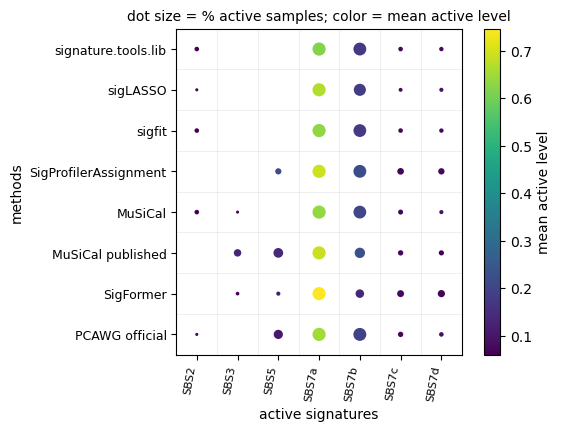

Stackbar config: sort=hclust | {'mode': 'hclust-average-cosine-OLO', 'source': 'SigFormer'}
Stackbar samples: total=86, shown=80, max_samples=80, subset=even
Stackbar signatures pass filter=7 | natural order: ['SBS2', 'SBS3', 'SBS5', 'SBS7a', 'SBS7b', 'SBS7c', 'SBS7d']
Stackbar signatures avg desc: [('SBS7a', 0.6667), ('SBS7b', 0.1608), ('SBS7d', 0.0251), ('SBS5', 0.0236), ('SBS7c', 0.0224), ('SBS3', 0.0064), ('SBS2', 0.0045)]


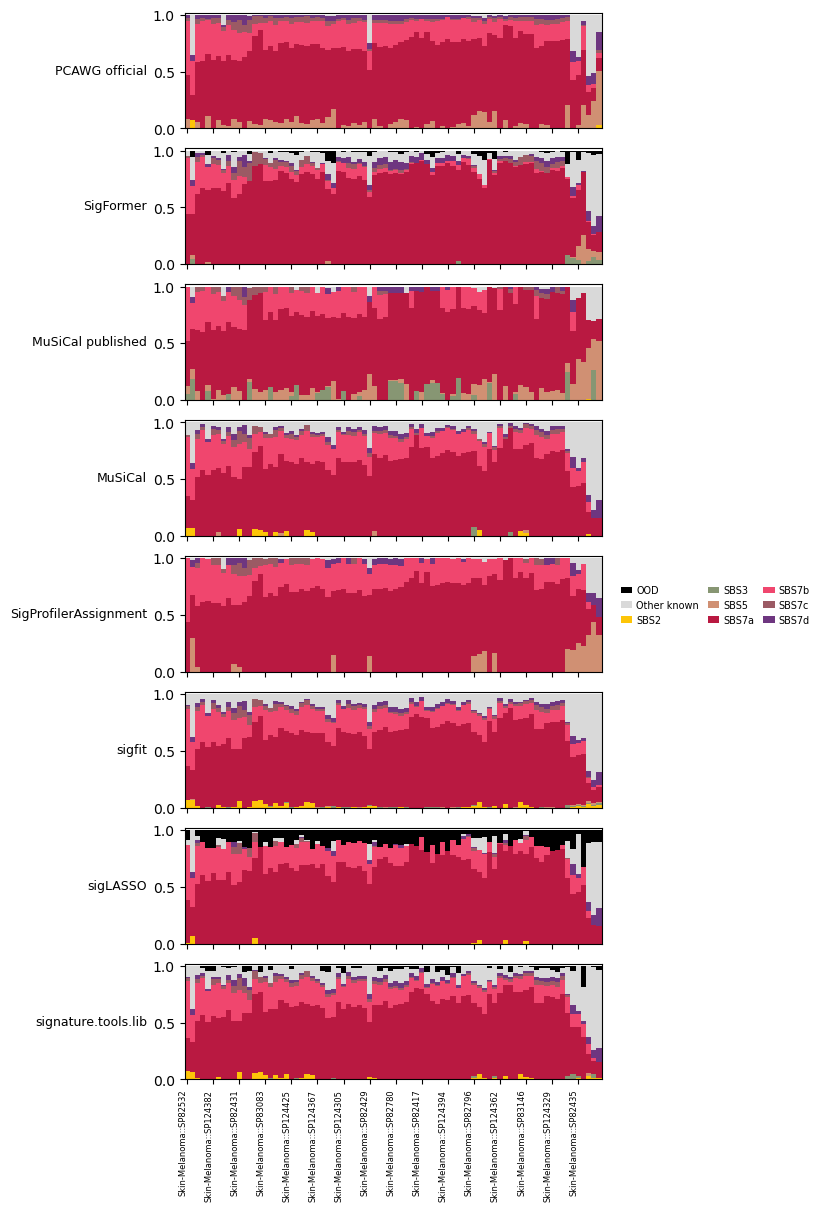

,0,1,2,3,4,5,6,7
method,PCAWG official,SigFormer,MuSiCal published,MuSiCal,SigProfilerAssignment,sigfit,sigLASSO,signature.tools.lib
n,125,125,125,125,125,125,125,125
displayed_mass,0.983037,0.909333,0.981756,0.857922,0.974589,0.666094,0.955198,0.770898


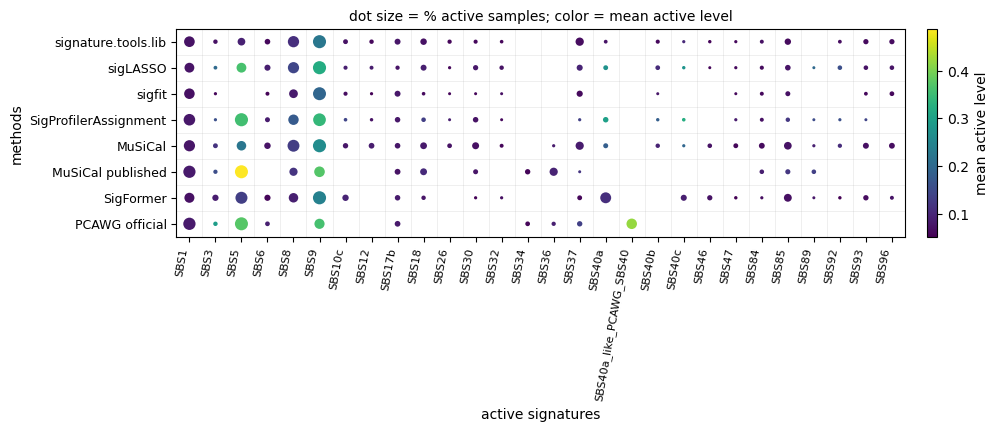

Stackbar config: sort=hclust | {'mode': 'hclust-average-cosine-OLO', 'source': 'SigFormer'}
Stackbar samples: total=125, shown=80, max_samples=80, subset=even
Stackbar signatures pass filter=28 | natural order: ['SBS1', 'SBS3', 'SBS5', 'SBS6', 'SBS8', 'SBS9', 'SBS10c', 'SBS12', 'SBS17b', 'SBS18', 'SBS26', 'SBS30', 'SBS32', 'SBS34', 'SBS36', 'SBS37', 'SBS40a', 'SBS40a_like_PCAWG_SBS40', 'SBS40b', 'SBS40c', 'SBS46', 'SBS47', 'SBS84', 'SBS85', 'SBS89', 'SBS92', 'SBS93', 'SBS96']
Stackbar signatures avg desc: [('SBS40a_like_PCAWG_SBS40', 0.2577), ('SBS9', 0.2485), ('SBS5', 0.2082), ('SBS8', 0.0689), ('SBS1', 0.0626), ('SBS40a', 0.0318), ('SBS85', 0.0223), ('SBS37', 0.0208), ('SBS17b', 0.0179), ('SBS18', 0.017), ('SBS6', 0.016), ('SBS93', 0.0134), ('SBS96', 0.0134), ('SBS3', 0.0134), ('SBS10c', 0.0127), ('SBS30', 0.0123), ('SBS84', 0.0115), ('SBS32', 0.0111), ('SBS40c', 0.0101), ('SBS40b', 0.0081), ('SBS12', 0.0068), ('SBS92', 0.0067), ('SBS34', 0.0065), ('SBS36', 0.0065), ('SBS47', 0.0064)

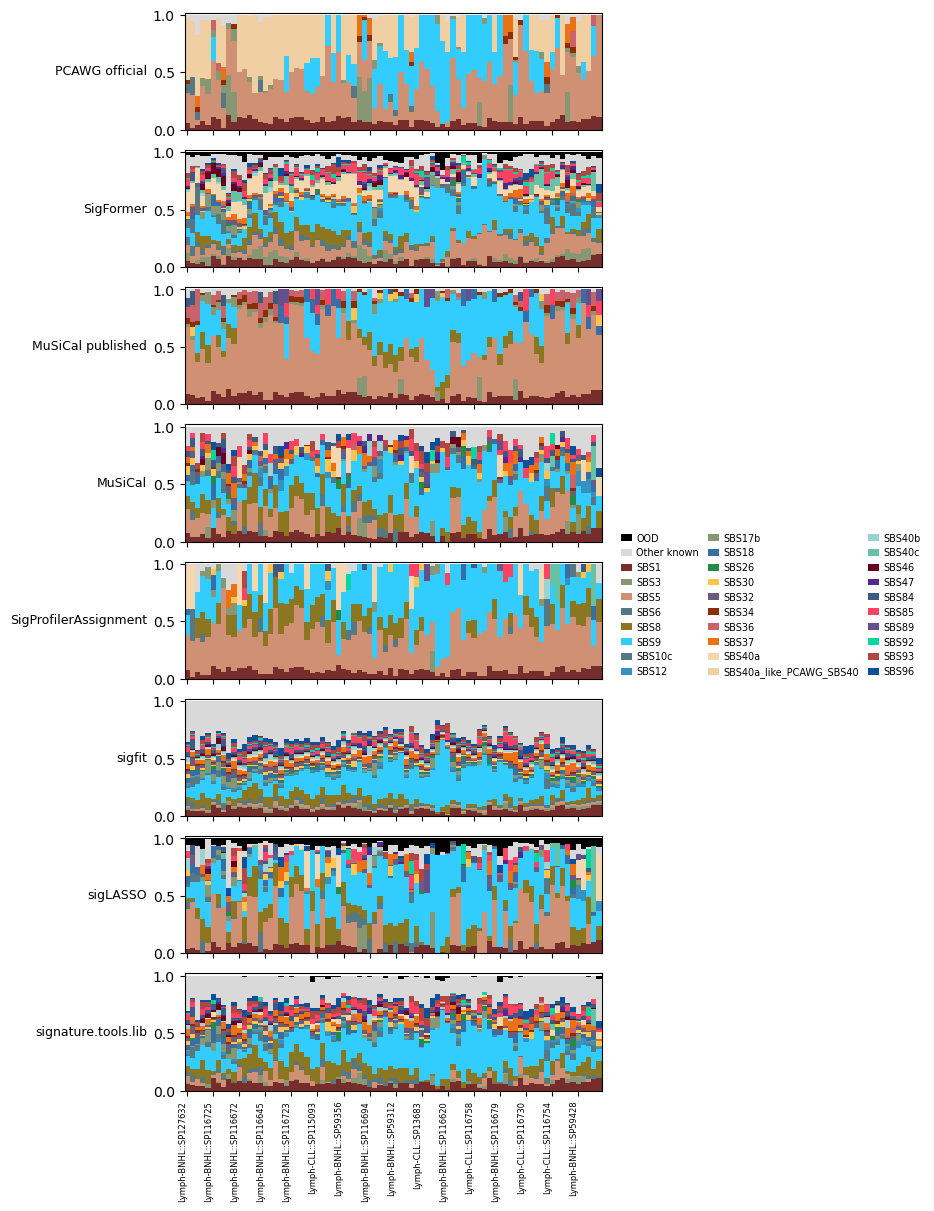

,0,1,2,3,4,5,6,7
method,PCAWG official,SigFormer,MuSiCal published,MuSiCal,SigProfilerAssignment,sigfit,sigLASSO,signature.tools.lib
n,63,63,63,63,63,63,63,63
displayed_mass,0.972218,0.946241,0.956082,0.951495,0.985991,0.795289,0.987736,0.848095


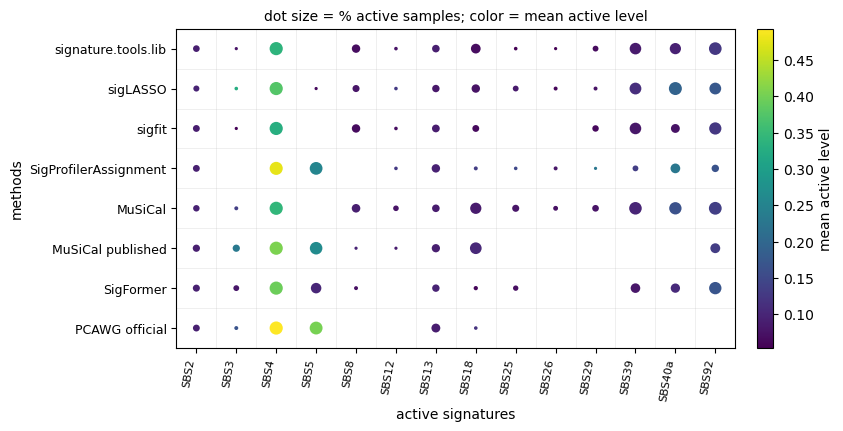

Stackbar config: sort=hclust | {'mode': 'hclust-average-cosine-OLO', 'source': 'SigFormer'}
Stackbar samples: total=63, shown=63, max_samples=80, subset=even
Stackbar signatures pass filter=14 | natural order: ['SBS2', 'SBS3', 'SBS4', 'SBS5', 'SBS8', 'SBS12', 'SBS13', 'SBS18', 'SBS25', 'SBS26', 'SBS29', 'SBS39', 'SBS40a', 'SBS92']
Stackbar signatures avg desc: [('SBS4', 0.3938), ('SBS5', 0.1176), ('SBS92', 0.1093), ('SBS40a', 0.1053), ('SBS39', 0.05), ('SBS13', 0.0399), ('SBS18', 0.0386), ('SBS2', 0.0341), ('SBS8', 0.0209), ('SBS3', 0.015), ('SBS25', 0.0115), ('SBS29', 0.0108), ('SBS12', 0.0066), ('SBS26', 0.0052)]


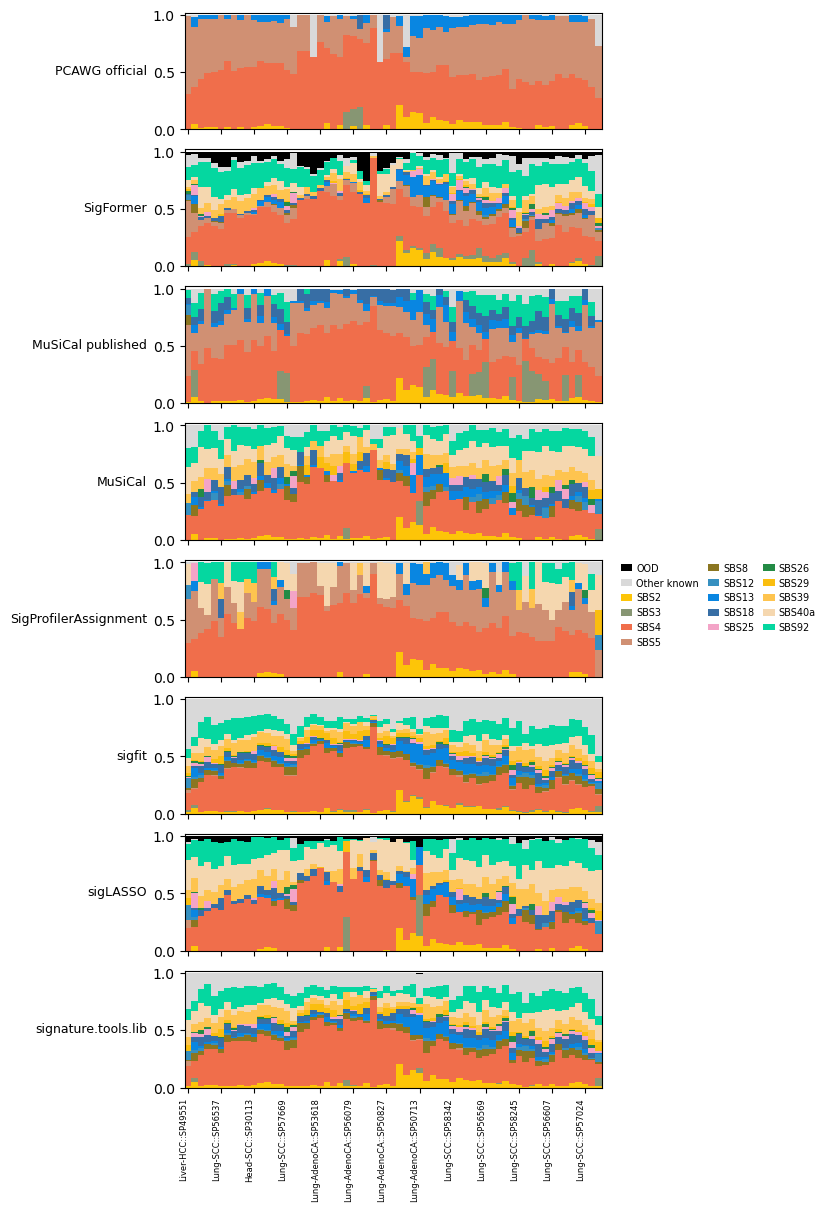

,0,1,2,3,4,5,6,7
method,PCAWG official,SigFormer,MuSiCal published,MuSiCal,SigProfilerAssignment,sigfit,sigLASSO,signature.tools.lib
n,43,43,43,43,43,43,43,43
displayed_mass,0.963562,0.90192,0.974432,0.869052,0.974467,0.82749,0.94178,0.840519


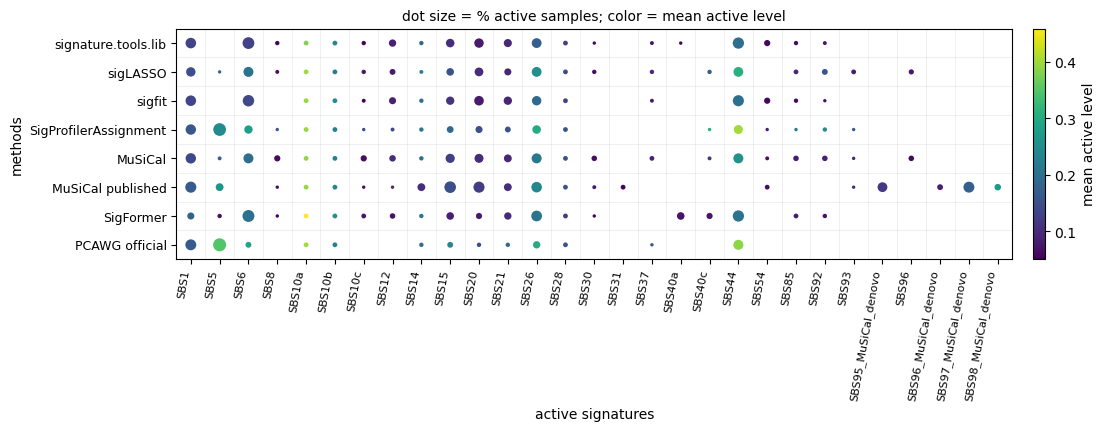

Stackbar config: sort=hclust | {'mode': 'hclust-average-cosine-OLO', 'source': 'SigFormer'}
Stackbar samples: total=43, shown=43, max_samples=80, subset=even
Stackbar signatures pass filter=29 | natural order: ['SBS1', 'SBS5', 'SBS6', 'SBS8', 'SBS10a', 'SBS10b', 'SBS10c', 'SBS12', 'SBS14', 'SBS15', 'SBS20', 'SBS21', 'SBS26', 'SBS28', 'SBS30', 'SBS31', 'SBS37', 'SBS40a', 'SBS40c', 'SBS44', 'SBS54', 'SBS85', 'SBS92', 'SBS93', 'SBS95_MuSiCal_denovo', 'SBS96', 'SBS96_MuSiCal_denovo', 'SBS97_MuSiCal_denovo', 'SBS98_MuSiCal_denovo']
Stackbar signatures avg desc: [('SBS44', 0.1429), ('SBS26', 0.1178), ('SBS97_MuSiCal_denovo', 0.1163), ('SBS6', 0.0946), ('SBS1', 0.0913), ('SBS5', 0.0852), ('SBS95_MuSiCal_denovo', 0.064), ('SBS15', 0.0576), ('SBS98_MuSiCal_denovo', 0.0566), ('SBS20', 0.0441), ('SBS10a', 0.0378), ('SBS21', 0.0324), ('SBS10b', 0.0238), ('SBS14', 0.0203), ('SBS12', 0.0163), ('SBS96_MuSiCal_denovo', 0.0146), ('SBS28', 0.0138), ('SBS10c', 0.0123), ('SBS92', 0.0113), ('SBS54', 0.0092

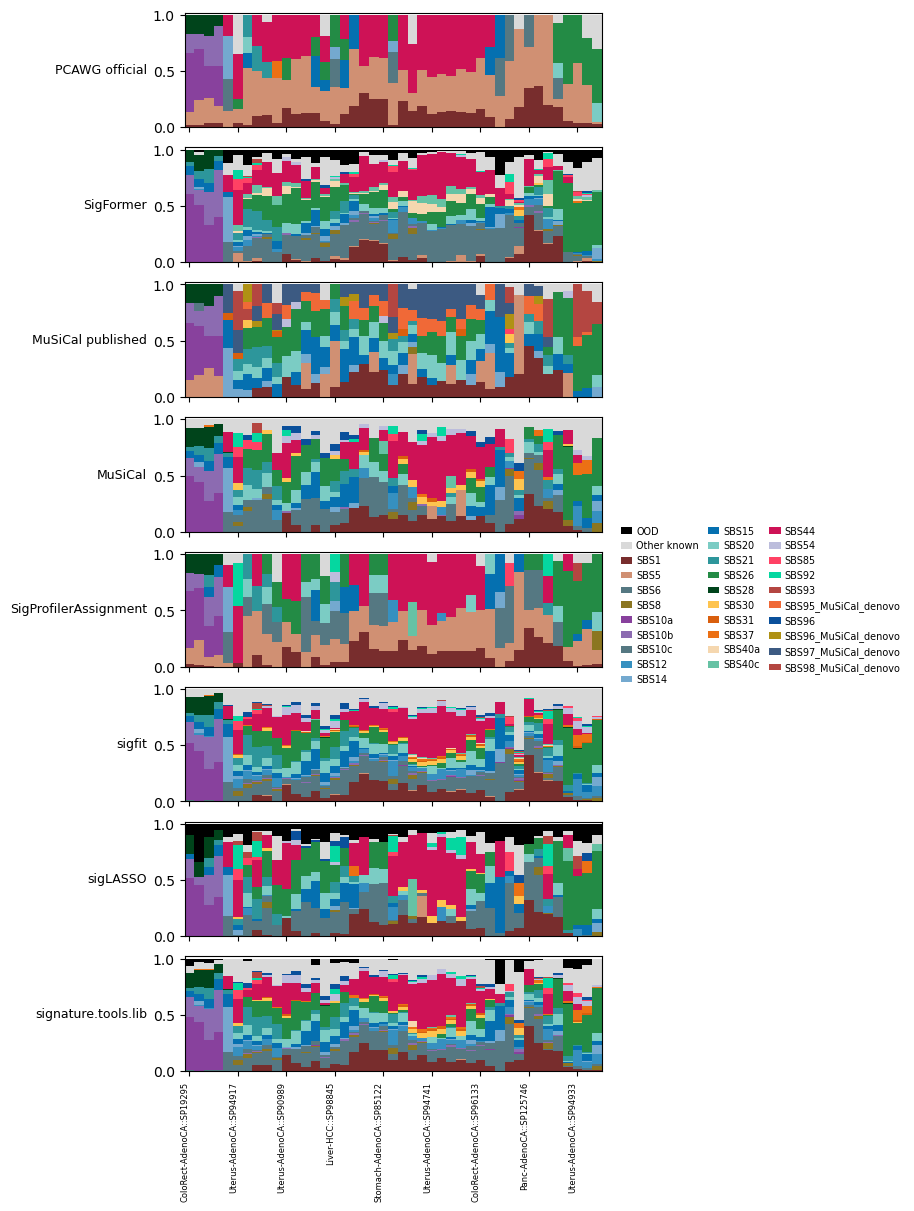

In [14]:
# Summarize each Leiden cluster with dotplots and stacked signature compositions.

cluster_labels = sorted(umap_meta[formal_cluster_col].dropna().astype(str).unique(), key=analysis.sig_natkey)
display(umap_meta[formal_cluster_col].value_counts().reindex(cluster_labels).rename('n_samples').to_frame().T)
CLUSTER_METHODS = [m for m in METHOD_ORDER if m in DICT_res]
max_smp, min_smp_frac, min_sig_expo = (80, 0.07, 0.05)

PARAM_dot = dict( min_sample_frac=min_smp_frac, min_weight=min_sig_expo, size_lim=(4, 90), cmap='viridis', size_by='pct_active', color_by='avg_active', size_range=(0, 1), show_grid=True,)
PARAM_bar = dict( min_sample_frac=min_smp_frac, min_weight=min_sig_expo, sort='hclust', hclust_tag='SigFormer', max_samples=max_smp, sample_subset='even', use_aligned_umap=True, xtick_every=5, xtick_rotation=90, xtick_fontsize=6, legend_ncol=3, size_sig_legend=7, ood_key='ood', verbose=True,)

for cluster in ['C14', 'C13', 'C16', 'C17']:
    loc = umap_meta.index[umap_meta[formal_cluster_col].astype(str).eq(cluster)]
    outdir = analysis.ensure_dir(PATH_cohort_CLUS / cluster)
    M_smp_meta.loc[loc, 'Tissue'].value_counts().rename('n').to_frame().to_csv(outdir / 'top_tissue.tsv', sep='\t')
    
    ### dot plot
    fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
    dot = analysis.plot_cluster_dotplot(ax, DICT_res, loc, methods=CLUSTER_METHODS, **PARAM_dot)
    dot.to_csv(outdir / f'{cluster}_dotplot_data.tsv', sep='\t', index=False)
    fig.savefig(outdir / f'{cluster}_dotplot.pdf')
    plt.show() ; plt.close(fig)
    
    ### signature stacked barplot
    fig, axes = plt.subplots(len(CLUSTER_METHODS), 1, figsize=(6, max(8, 1.5 * len(CLUSTER_METHODS))), sharex=True, constrained_layout=True)
    stack = analysis.plot_cluster_stackbar(axes, DICT_res, umap_meta, loc, methods=CLUSTER_METHODS, sig_colors=SIG_COLORS, **PARAM_bar)
    order_table = {'shown_order': pd.Series(stack['shown_order'], dtype=object),
                    'full_order': pd.Series(stack[ 'full_order'], dtype=object),}
    pd.DataFrame(order_table).to_csv(outdir / f'{cluster}_stackbar_order.tsv', sep='\t', index=False)
    stack['sig_avg_desc'].rename('mean_composition').to_csv(outdir / f'{cluster}_stackbar_signature_mean.tsv', sep='\t')
    fig.savefig(outdir / f'{cluster}_stacked_bar.pdf')
    plt.show() ; plt.close(fig)

---

## 5. Standardized replacement test

In [15]:
# Standardized replacement tests for selected cluster/source/target hypotheses.

Replacement_groups = {
    'C13': {'source': ['SBS3', 'SBS5'],
            'target': ['SBS9'],
             'title': 'C12: SBS3/SBS5 → SBS9',},
    'C14': {'source': ['SBS5'],
            'target': ['SBS7c', 'SBS7d'],
             'title': 'C14: SBS5 → SBS7c+SBS7d',},
    'C16': {'source': ['SBS5'],
            'target': ['SBS40a'],
             'title': 'C16: SBS5 → SBS40a',},
}
replacement_METHODS = [m for m in METHOD_ORDER if m in DICT_res]

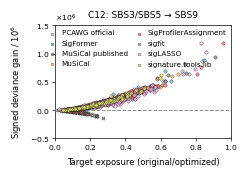

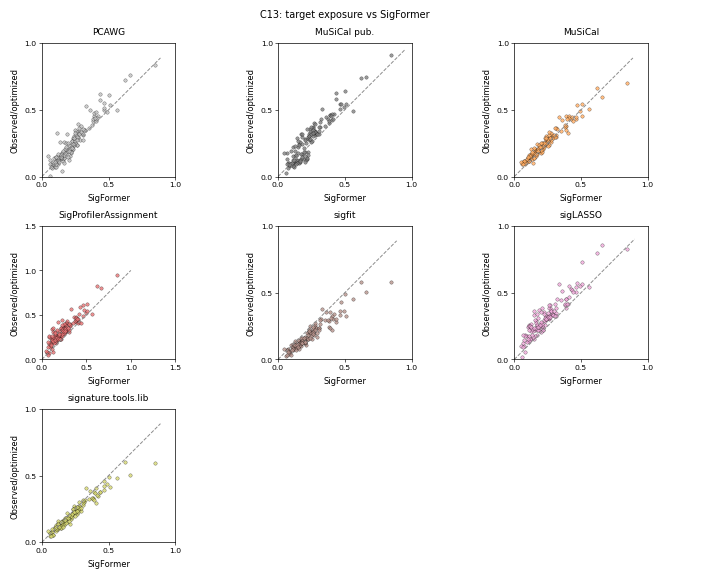

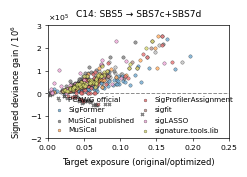

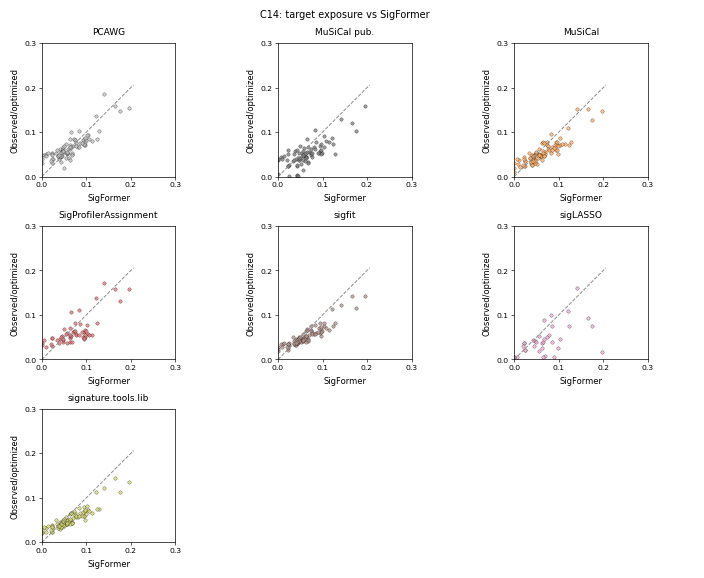

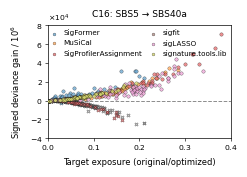

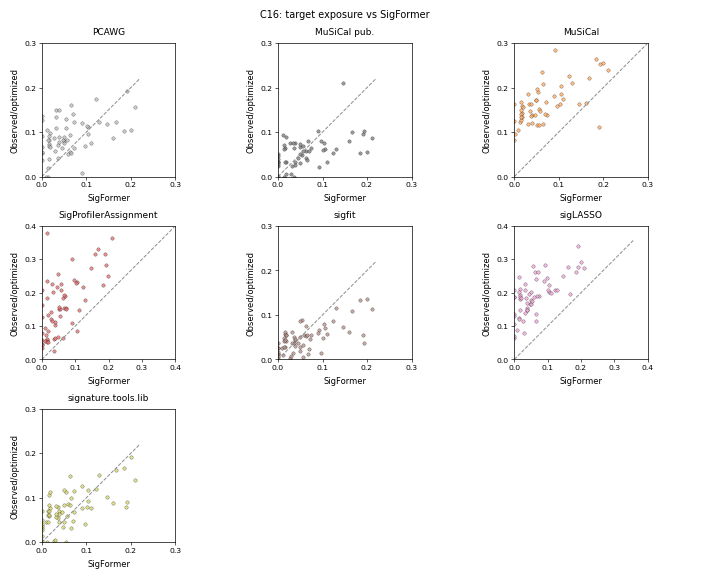

In [16]:
# Save per-cluster positive residual profiles and their cosine-similarity heatmap.

Replacement_summary = []
for cluster, cfg in Replacement_groups.items():
    loc = umap_meta.index[umap_meta[formal_cluster_col].astype(str).eq(cluster)]
    profiles = X_raw_prof.loc[loc]
    compo_by_method = {m: DICT_res[m]['compo'].reindex(loc) for m in replacement_METHODS}
    method_results = {}
    for method, compo in compo_by_method.items():
        result = analysis.replacement_test(df_profile=profiles, df_compo=compo, df_refseq=R_harmonized, sig_source=cfg['source'], sig_target=cfg['target'], presence_threshold=0.0001, score_scale=1000000.0)
        method_results[method] = result
        result.to_csv(PATH_cohort_REPL / f"{cluster}_{re.sub('[^A-Za-z0-9_.-]+', '_', method)}_replacement.tsv", sep='\t')
        tested = result[result['testable'].fillna(False)]
        for present, group in tested.groupby('present'):
            expected = group['signed_deviance_gain'].gt(0) if present else group['signed_deviance_gain'].lt(0)
            Replacement_summary.append({
                'cluster': cluster,
                'method': method,
                'present': present,
                'n': len(group),
                'median_signed_deviance_gain': group['signed_deviance_gain'].median(),
                'expected_sign_fraction': np.mean(expected),
                'median_original_target': group['original_target'].median(),
                'median_optimized_target': group['optimized_target'].median(),
            })
    fig, ax = analysis.plot_replacement_scatter(results=method_results, title=cfg['title'], fig_path=PATH_cohort_REPL / f'z_{cluster}_replacement_scatter.pdf')
    plt.show() ; plt.close(fig)
    fig, axes, stats = analysis.plot_optimized_vs_sigformer(method_results=method_results, df_sigformer=compo_by_method['SigFormer'], sig_target=cfg['target'], title=f'{cluster}: target exposure vs SigFormer', fig_path=PATH_cohort_REPL / f'z_{cluster}_optimized_vs_SigFormer.pdf')
    stats.to_csv(PATH_cohort_REPL / f'{cluster}_optimized_vs_SigFormer_stats.tsv', sep='\t')
    plt.show() ; plt.close(fig)
pd.DataFrame(Replacement_summary).to_csv(PATH_cohort_REPL / 'Replacement_summary.tsv', sep='\t', index=False)